In [3]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torchvision
from tqdm import tqdm

import pickle
from matplotlib import pyplot as plt

## 2. Targeted Attack

- 你已经实现了FGSM和PGD算法上的无目标攻击，接下来请实现两种算法上的有目标攻击

- 具体实验步骤如下：
  
  1. 将代码文件上传到服务器端根目录，将week5保存的lenet5.pt迁移到/model路径下
   
  2. 在服务器端根目录下新建目录data，并将week6新版样本数据（Week567_img_label.pkl）上传至/data目录下
   
  3. 依照提示，完成Python文件中`fgsm_target(imgs, epsilon, model, criterion, labels)`函数和`pgd_target(imgs, epsilon, iter, model, criterion, labels)`函数的*TODO*内容
   
  4. 执行代码完成攻击与效果验证

In [1]:
from Week567_General_Code_Question import LeNet5, fgsm_target, pgd_target, evaluate
from Week567_General_Code_Question import visualize_target_adv

### 目标模型加载

注意，请将week5保存的lenet5.pt迁移到/model路径下

In [4]:
model = LeNet5()
### 请将week5保存的lenet5.pt迁移到/model路径下
model.load_state_dict(torch.load('model/lenet5.pt'))
model.eval()

criterion = nn.CrossEntropyLoss()

### 读入待攻击的样本

注意，需导入week6的新版本Week567_img_label.pkl

In [5]:
with open('data/Week567_img_label.pkl', 'rb') as f:
    data = pickle.load(f)
    imgs, labels, target_labels = data['img'], data['label'], data['target_label']

### 2.1 FGSM

依照提示，完成Python文件中`fgsm_target(imgs, epsilon, model, criterion, labels)`函数的*TODO*内容：

  - labels参数为各样本的攻击目标类
       
  - 根据模型对样本预测结果计算与攻击目标类的loss，并回传、方便梯度获取 

  - 实现有目标FGSM对抗样本生成过程

  - **助教检查**时测试扰动大小$\epsilon=0.2$

  - **正确实现**要求match rate $ \ge 0.4$
    - *注: 若多次尝试后，仍未达到验收目标，推荐设置LeNet5中卷积层的kernel_size=5
  
  - 实现后评测对抗样本的攻击效果

下面是一些供你参考/可能用到的API函数：
- torch.Tensor.requires_grad [Link](https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad.html)
  - 设置tensor是否加入计算图，即是否需要反向累积梯度
- torch.Tensor.grad [Link](https://pytorch.org/docs/stable/generated/torch.Tensor.grad.html)
  - 在loss.backward()后，获取tensor上的梯度
- torch.Tensor.sign() [Link](https://pytorch.org/docs/stable/generated/torch.Tensor.sign.html)
  - 取一个tensor中每个元素的符号（正负1），返回的形状与输入相同
- torch.clamp(*input*, *min=None*, *max=None*, ***, *out=None*) [Link](https://pytorch.org/docs/stable/generated/torch.clamp.html)
  - input: 需要clip的tensor
  - min, max: 截断的阈值，使tensor中在[min, max]以外的值被截断至min或max
- torch.Tensor.detach() [Link](https://pytorch.org/docs/stable/generated/torch.Tensor.detach.html)
  - 获取一个脱离计算图的tensor，获得的tensor不再会被反向计算梯度

In [6]:
# perform fgsm attack and evaluate
epsilon = 0.2
fgsm_xs = fgsm_target(imgs, epsilon, model, criterion, target_labels)
pred_label = evaluate(fgsm_xs, target_labels, model)

match rate: 0.4


### 可视化对抗样本与结果

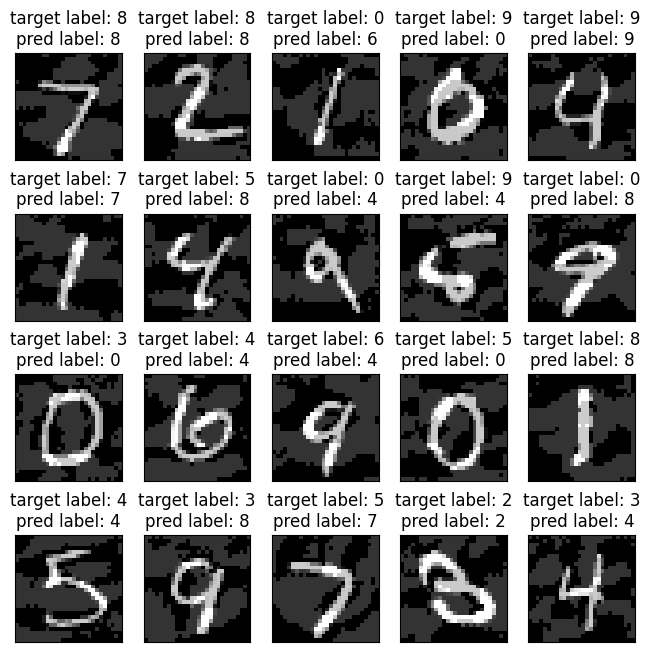

In [7]:
fgsm_imgs = fgsm_xs.reshape_as(imgs)
visualize_target_adv(fgsm_imgs, target_labels, pred_label)

### 2.2 PGD

依照提示，完成Python文件中`pgd_target(imgs, epsilon, iter, model, criterion, labels)`函数的*TODO*内容：

  - labels参数为各样本的攻击目标类
       
  - 根据模型对样本预测结果计算与攻击目标类的loss，并回传、方便梯度获取 

  - 实现有目标PGD对抗样本生成过程，在iter轮的优化过程中生成对抗扰动

  - **助教检查**时测试扰动大小$\epsilon=0.2$、攻击轮次$iter \in [5, 15, 30]$、单步步长$\alpha \in [0.03, 0.07, 0.15]$

  - **正确实现**要求**最佳攻击效果**的match rate $ \ge 0.75$
    - *注: 若多次尝试后，仍未达到验收目标，推荐设置LeNet5中卷积层的kernel_size=5
  
  - 实现后评测对抗样本的攻击效果

下面是一些供你参考/可能用到的API函数：
- torch.Tensor.requires_grad [Link](https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad.html)
  - 设置tensor是否加入计算图，即是否需要反向累积梯度
- torch.Tensor.grad [Link](https://pytorch.org/docs/stable/generated/torch.Tensor.grad.html)
  - 在loss.backward()后，获取tensor上的梯度
- torch.Tensor.sign() [Link](https://pytorch.org/docs/stable/generated/torch.Tensor.sign.html)
  - 取一个tensor中每个元素的符号（正负1），返回的形状与输入相同
- torch.clamp(*input*, *min=None*, *max=None*, ***, *out=None*) [Link](https://pytorch.org/docs/stable/generated/torch.clamp.html)
  - input: 需要clip的tensor
  - min, max: 截断的阈值，使tensor中在[min, max]以外的值被截断至min或max
- torch.Tensor.detach() [Link](https://pytorch.org/docs/stable/generated/torch.Tensor.detach.html)
  - 获取一个脱离计算图的tensor，获得的tensor不再会被反向计算梯度

In [8]:
# perform pgd attack and evaluate
epsilon = 0.2
iter = 5
alpha = 0.07
pgd_xs = pgd_target(imgs, epsilon, alpha, iter, model, criterion, target_labels)
pred_label = evaluate(pgd_xs, target_labels, model)

match rate: 0.75


### 可视化对抗样本与结果

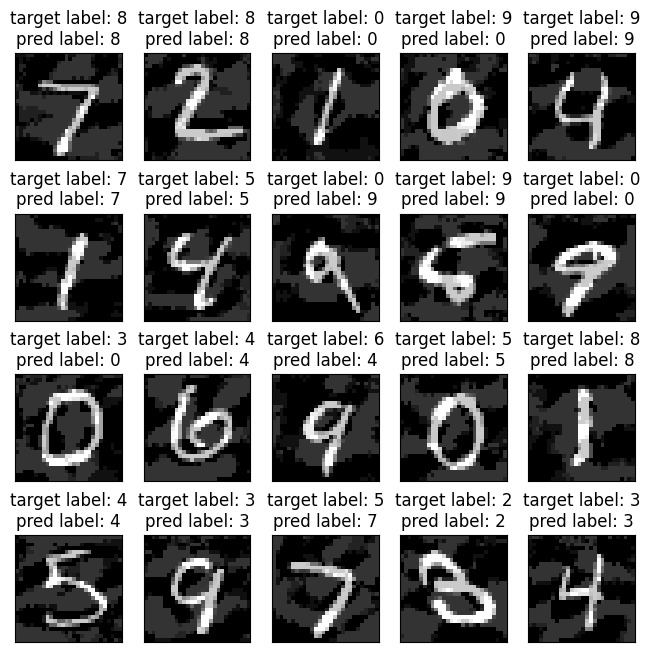

In [9]:
pgd_imgs = pgd_xs.reshape_as(imgs)
visualize_target_adv(pgd_imgs, target_labels, pred_label)

### 比较有目标攻击下的FGSM与PGD对抗样本

In [10]:
# Compute perturbation from original img
delta_fgsm = fgsm_imgs - imgs
delta_pgd = pgd_imgs - imgs

# Compute L2 distance
print(f'L2_FGSM: {delta_fgsm.pow(2).sum(dim=-1).sqrt().mean()}')
print(f'L2_PGD: {delta_pgd.pow(2).sum(dim=-1).sqrt().mean()}')

L2_FGSM: 0.7822007536888123
L2_PGD: 0.7118218541145325
